In [36]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.utils.plotting import plot_series
from sktime.forecasting.base import ForecastingHorizon

In [27]:
# Load the dataset (NASA GISTEMP Global Temperature Anomaly)
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

In [28]:
# Data preparation
def prepare_nasa_data(url):
    # Read the data, skipping the header explanation
    df = pd.read_csv(url, skiprows=1)

    # Remove the unnecessary columns
    df = df.iloc[:, :13]

    # Rename columns
    df.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Convert from wide to long format
    df_long = df.melt(id_vars=['Year'],
                       var_name='Month',
                       value_name='Temperature_Anomaly')
    
        # Filter out missing or invalid data
    df_long = df_long[df_long['Temperature_Anomaly'] != '***']
    df_long['Temperature_Anomaly'] = df_long['Temperature_Anomaly'].astype(float)
    
     # Create a proper date index
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Month'], format='%Y-%b')
    
     # Sort by date
    df_long = df_long.sort_values('Date')
    
       # Create a time series
    ts_data = df_long.set_index('Date')['Temperature_Anomaly']

    return ts_data

In [29]:
# Prepare the time series data
ts_data = prepare_nasa_data(url)

In [30]:
# Now you have a time series object 'ts_data' to work with
print(f"Time series data from {ts_data.index.min()} to {ts_data.index.max()}")
print(f"Total number of observations: {len(ts_data)}")


Time series data from 1880-01-01 00:00:00 to 2025-03-01 00:00:00
Total number of observations: 1743


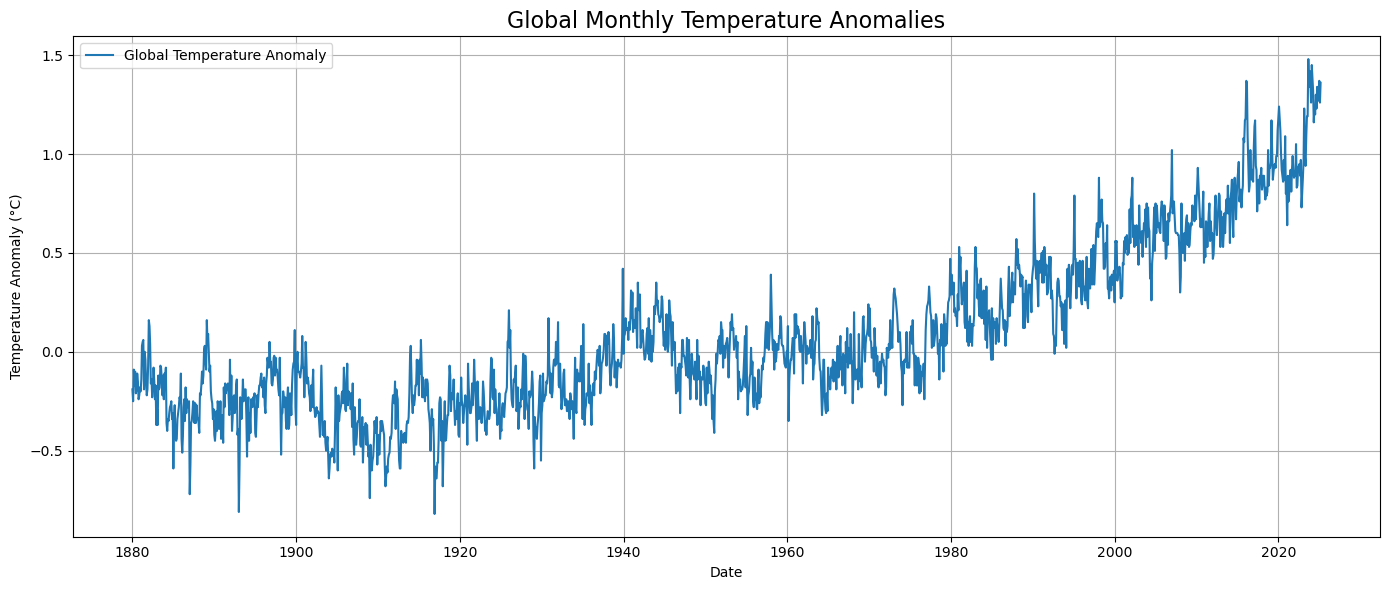

In [31]:
plt.figure(figsize=(14, 6))
plt.plot(ts_data, label="Global Temperature Anomaly", linewidth=1.5)
plt.title("Global Monthly Temperature Anomalies", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


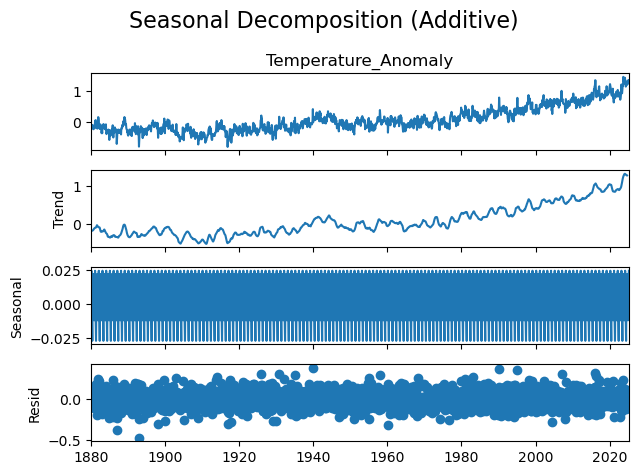

In [32]:
decomposition = seasonal_decompose(ts_data, model='additive', period=12)
decomposition.plot()
plt.suptitle("Seasonal Decomposition (Additive)", fontsize=16)
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

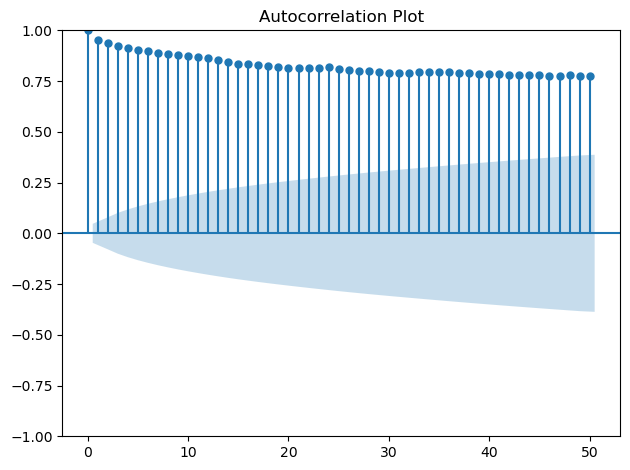

In [33]:
plt.figure(figsize=(10, 5))
plot_acf(ts_data, lags=50)
plt.title("Autocorrelation Plot")
plt.tight_layout()
plt.show()


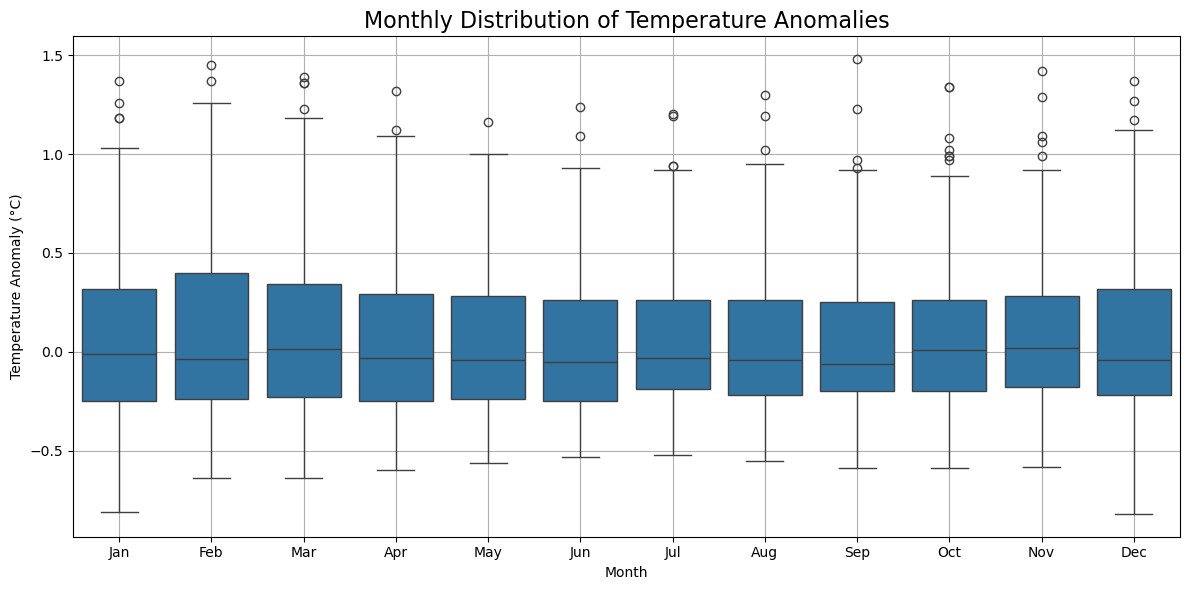

In [38]:

df_monthly = ts_data.reset_index()
df_monthly['Month'] = df_monthly['Date'].dt.strftime('%b')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Temperature_Anomaly', data=df_monthly, order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Monthly Distribution of Temperature Anomalies", fontsize=16)
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


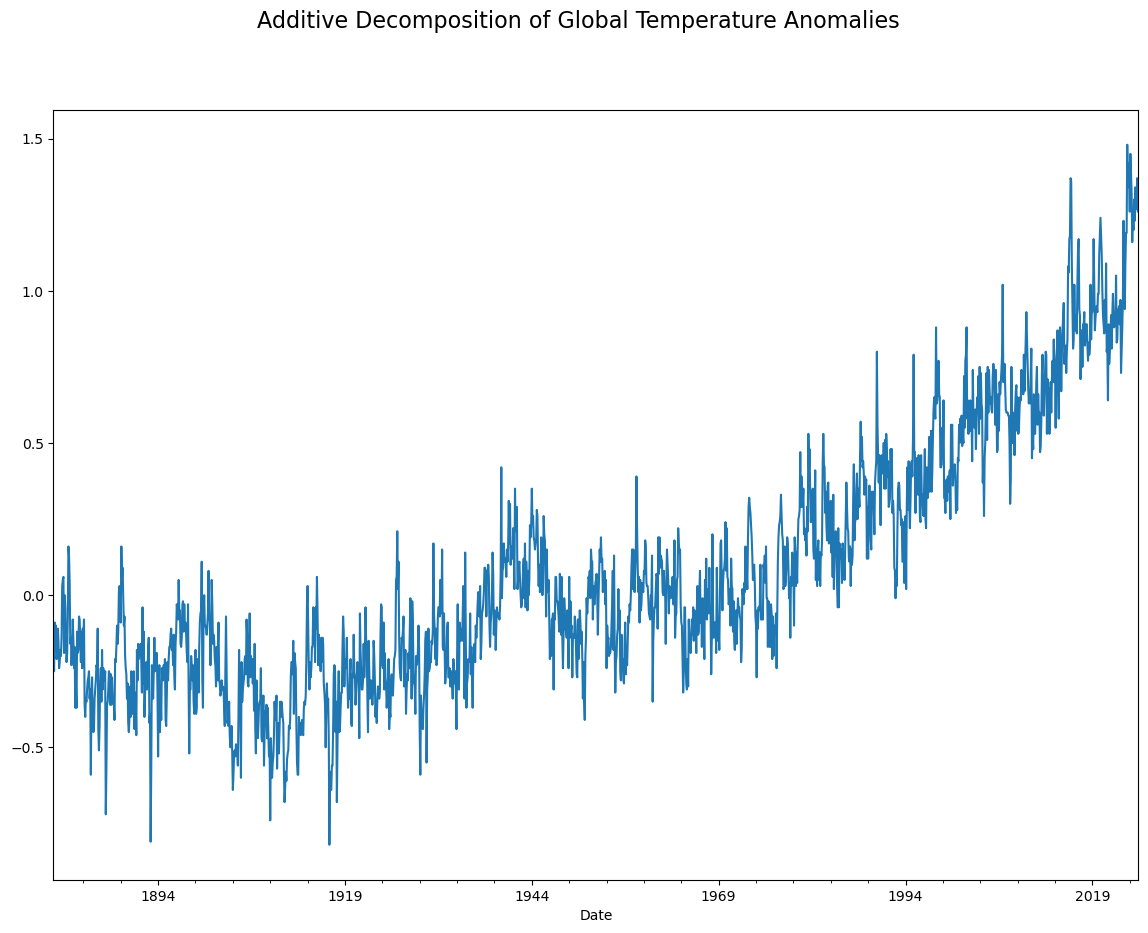

In [ ]:
plt.figure(figsize=(14, 10))
ts_data.plot()
plt.suptitle('Additive Decomposition of Global Temperature Anomalies', fontsize=16)
plt.show()

In [39]:

result_mul = seasonal_decompose(ts_data, model='multiplicative', period=12)

fig = result_mul.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Multiplicative Decomposition of Global Temperature Anomalies', fontsize=16)
plt.show()

# ts_data has negative values hence multiplicative decomposition CANNOT be used.

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

In [41]:

print(f"Training data: {len(train)} observations from {train.index.min()} to {train.index.max()}")
print(f"Testing data: {len(test)} observations from {test.index.min()} to {test.index.max()}")

Training data: 1707 observations from 1880-01-01 00:00:00 to 2022-03-01 00:00:00
Testing data: 36 observations from 2022-04-01 00:00:00 to 2025-03-01 00:00:00


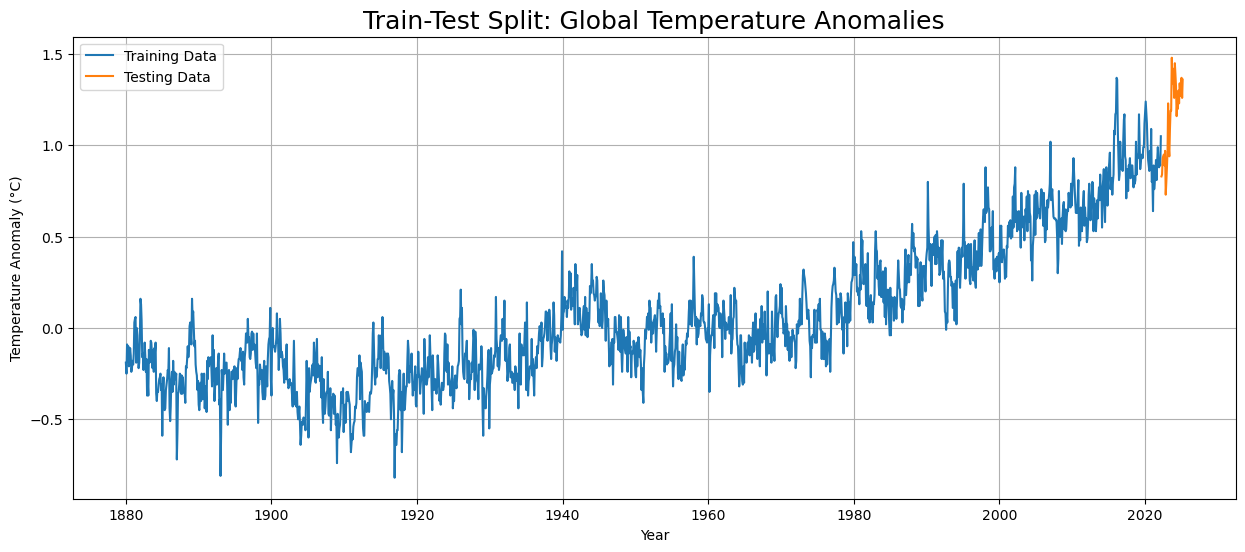

In [40]:
train, test = temporal_train_test_split(ts_data, test_size=36)
plt.figure(figsize=(15,6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data')
plt.title('Train-Test Split: Global Temperature Anomalies', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0  # avoid division by zero
    return np.mean(diff) * 100

def clean_timeseries_for_sktime(y, freq='MS'):
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("Index must be a pandas DatetimeIndex")

    full_idx = pd.date_range(start=y.index.min(), end=y.index.max(), freq=freq)
    y = y.reindex(full_idx)
    y = y.interpolate(method='linear').bfill().ffill()
    y.index.freq = freq
    return y

def compare_arima_vs_ets(series, forecast_periods=12, freq='MS'):
   
    series = clean_timeseries_for_sktime(series, freq)

    train = series.iloc[:-forecast_periods]
    test = series.iloc[-forecast_periods:]
    fh = ForecastingHorizon(np.arange(1, forecast_periods + 1), is_relative=True)

    # AutoARIMA
    arima = AutoARIMA(sp=12, suppress_warnings=True).fit(train)
    arima_pred = arima.predict(fh)
    arima_mae = mean_absolute_error(test, arima_pred)
    arima_smape = smape(test.values, arima_pred.values)

    # AutoETS
    ets = AutoETS(auto=True, sp=12).fit(train)
    ets_pred = ets.predict(fh)
    ets_mae = mean_absolute_error(test, ets_pred)
    ets_smape = smape(test.values, ets_pred.values)

    print("Forecasting Model Comparison:")
    print(f"AutoARIMA → MAE: {arima_mae:.4f} | sMAPE: {arima_smape:.2f}%")
    print(f"AutoETS  → MAE: {ets_mae:.4f} | sMAPE: {ets_smape:.2f}%")

 
    if arima_mae < ets_mae:
        print("\nBest model: AutoARIMA")
        return "AutoARIMA", arima_pred
    else:
        print("\nBest model: AutoETS")
        return "AutoETS", ets_pred


In [ ]:

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (sMAPE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0  # avoid division by zero
    return np.mean(diff) * 100

def clean_timeseries_for_sktime(y, freq='MS'):
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("Index must be a pandas DatetimeIndex")
    full_idx = pd.date_range(start=y.index.min(), end=y.index.max(), freq=freq)
    y = y.reindex(full_idx).interpolate(method='linear').bfill().ffill()
    y.index.freq = freq
    return y

def compare_arima_vs_ets(series, forecast_periods=12, freq='MS'):
   
    series = clean_timeseries_for_sktime(series, freq)

    train = series.iloc[:-forecast_periods]
    test = series.iloc[-forecast_periods:]
    fh = ForecastingHorizon(np.arange(1, forecast_periods + 1), is_relative=True)


    arima = AutoARIMA(sp=12, suppress_warnings=True).fit(train)
    arima_pred = arima.predict(fh)
    arima_mae = mean_absolute_error(test, arima_pred)
    arima_smape = smape(test.values, arima_pred.values)


    ets = AutoETS(auto=True, sp=12).fit(train)
    ets_pred = ets.predict(fh)
    ets_mae = mean_absolute_error(test, ets_pred)
    ets_smape = smape(test.values, ets_pred.values)


    print("Forecasting Model Evaluation (ARIMA vs ETS):")
    print("-" * 50)
    print(f"{'Model':<12} | {'MAE':>10} | {'sMAPE':>10}")
    print("-" * 50)
    print(f"{'AutoARIMA':<12} | {arima_mae:10.4f} | {arima_smape:9.2f}%")
    print(f"{'AutoETS':<12} | {ets_mae:10.4f} | {ets_smape:9.2f}%")
    print("-" * 50)

    if arima_mae < ets_mae:
        print("Best model based on MAE: AutoARIMA")
        return "AutoARIMA", arima_pred
    else:
        print("Best model based on MAE: AutoETS")
        return "AutoETS", ets_pred
